In [153]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from COMPAS.compas_python_utils.detailed_evolution_plotter import plot_detailed_evolution as det_evo
import tempfile

import h5py as h5 
from astropy import units as u
from astropy import constants as c

import os
import scipy

pd.options.display.max_columns = None

In [154]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
# rcParams['font.family'] = 'serif'
# rcParams["mathtext.fontset"] = 'stix'
# rcParams["font.size"] = 18
fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "12",
    "xtick.labelsize": "10",
    "ytick.labelsize": "10",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images


In [155]:
from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))
color_list = [colorPalette['red'], colorPalette['blue'], colorPalette['green']]

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']


In [156]:
columns_to_keep = ['Time', 'Mass(1)', 'Mass(2)', 'Radius(1)', 'Radius(2)', 'SemiMajorAxis', 'Eccentricity', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Period(1)', 'Period(2)', 'Period_Orb', 'dmMT(1)', 'dmMT(2)', 'Omega(1)', 'Omega(2)', 'Omega_Orb', 'Record_Type']
columns_to_keep_sanity = ['Time', 'M1', 'M2', 'R1', 'R2', 'SemiMajorAxis_Rsun', 'ecc', 'StellarType_1', 'StellarType_2', 'Period1', 'Period2', 'Period_orb', 'dM1_MT', 'dM2_MT']


1. INITIAL_STATE
    Record describes the initial state of the binary

2. POST_STELLAR_TIMESTEP
    Record was logged immediately following stellar timestep (i.e. the evolution of the constituent stars for a single timestep)

3.  POST_BINARY_TIMESTEP
    Record was logged immediately following binary timestep (i.e. the evolution of the binary system for a single timestep)

4.  TIMESTEP_COMPLETED
    Record was logged immediately following the completion of the timestep (after all changes to the binary and components)

5.  FINAL_STATE
    Record describes the final state of the binary

6.  STELLAR_TYPE_CHANGE_DURING_CEE
    Record was logged immediately following a stellar type change during a common envelope event

7.  STELLAR_TYPE_CHANGE_DURING_MT
    Record was logged immediately following a stellar type change during a mass transfer event

8.  STELLAR_TYPE_CHANGE_DURING_MASS_RESOLUTION
    Record was logged immediately following a stellar type change during mass resolution

9.  STELLAR_TYPE_CHANGE_DURING_CHE_EQUILIBRATION
    Record was logged immediately following a stellar type change during mass equilibration for CHE

10.  POST_MT
    Record was logged immediately following a mass transfer event

11.  POST_WINDS
    Record was logged immediately following winds mass loss

12.  POST_CEE
    Record was logged immediately following a common envelope event

13.  POST_SN
    Record was logged immediately following a supernova event

14.  POST_MASS_RESOLUTION
    Record was logged immediately following mass resolution (i.e. after winds mass loss & mass transfer complete)

15.  POST_MASS_RESOLUTION_MERGER
    Record was logged immediately following a merger after mass resolution

16.  PRE_STELLAR_TIMESTEP
    Record was logged immediately prior to stellar timestep (i.e. the evolution of the constituent stars for a single timestep)


# SMT BBH that stays spinning with Tides

In [167]:
# notides_DataPath = 'sim_data/smt_notides'
tides_DataPath = 'sim_data/smt_realistic'
perfect_DataPath = 'sim_data/smt_perfect'

# # --------------

# df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
# df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



# df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000061   Zero-age main-sequence, metallicity Z=0.0020   32.902     1     28.490     1     87.420  0.057
  6.192338   Star 1: MS->HG                    31.476     2     27.722     1     90.653  0.057
  6.195022   Stable mass transfer from 1 to 2   10.202     7     48.994     1    208.817  0.000
  6.195022   Star 1: HG->HeMS                  10.202     7     48.994     1    208.817  0.000
  6.833882   Star 1: HeMS->HeHG                10.092     8     48.395     1    215.275  0.000
  6.861699   Star 1 undergoes supernova and forms a BH   10.085    14     48.366     1    215.601  0.000
  8.541585   Star 2: MS->HG                    10.085    14     46.134     2    237.418  0.000
  8.543962   Stable mass transfer from 2 to 1   10.085    14     17.153     7     11.323  0.000
  8.543962   Star 2: HG->HeMS                  10.085    14     17.153     7     11.323  0.000
  9.008888   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1747fcf10>])

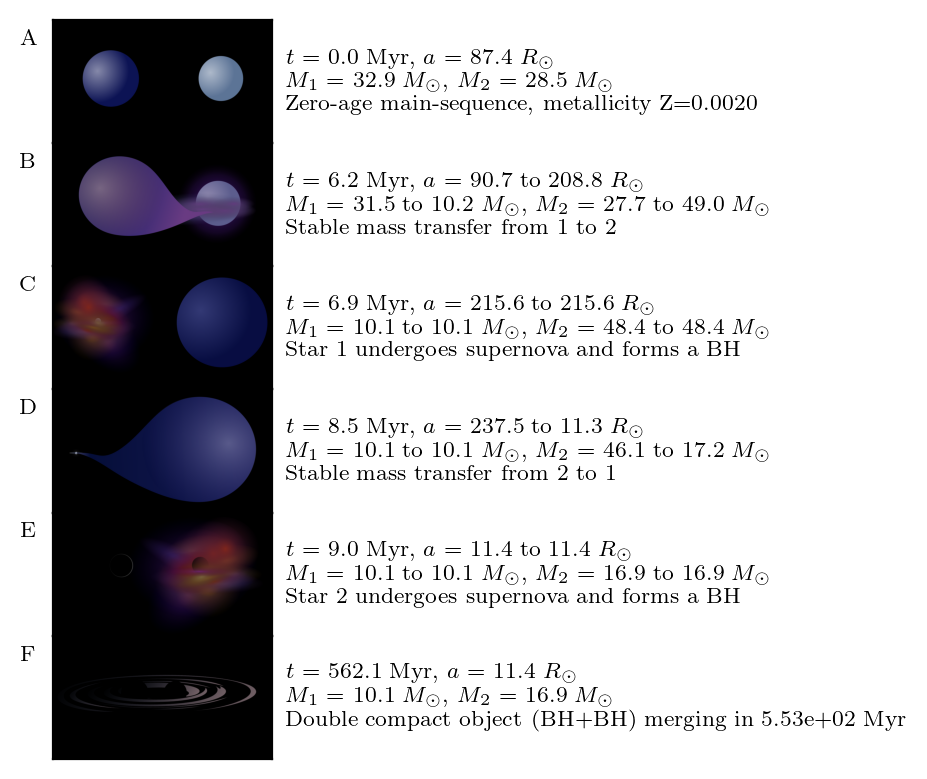

In [168]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [169]:
df_detailed_tides['Period(1)'] = (2 * np.pi / (df_detailed_tides['Omega(1)'].values / u.s)).to(u.day)
df_detailed_tides['Period(2)'] = (2 * np.pi / (df_detailed_tides['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_tides['Mass(1)'].values * u.M_sun + df_detailed_tides['Mass(2)'].values * u.M_sun) / (df_detailed_tides['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_tides['Omega_Orb'] = omega_orb.value
df_detailed_tides['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_tides_short = df_detailed_tides[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [170]:
# st_change_idx = np.where((df_detailed_tides['Stellar_Type(1)'] != df_detailed_tides['Stellar_Type(1)'].shift()) | (df_detailed_tides['Stellar_Type(2)'] != df_detailed_tides['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_tides_short.iloc[st_changes_with_buffer] # the +1 is to get the row after the change, which is after tidal effects

In [171]:
df_dco_tides

,SEED,SemiMajorAxis@DCO,Eccentricity@DCO,Mass(1),Stellar_Type(1),Mass(2),Stellar_Type(2),Coalescence_Time,Time,Merges_Hubble_Time,Recycled_NS(1),Recycled_NS(2),Record_Type
0,902,0.053004,0.0,10.084761,14,16.862146,14,553.781489,9.012475,1,0,0,1


In [172]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

In [173]:
df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)


df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

In [174]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,32.9017,28.4904,6.264330,5.753160,87.420248,5.707070e-02,1,1,6.743101e+06,8.383717e+06,12.083621,0.00000,0.0000
1430,6.19234,31.4757,27.7219,15.907100,12.331600,90.653471,5.702470e-02,1,1,3.626284e+03,2.597865e+03,12.994504,0.00000,0.0000
1431,6.19234,31.4755,27.7218,15.583600,12.331500,90.653901,5.702470e-02,2,1,2.368543e+03,2.597901e+03,12.994652,0.00000,0.0000
2081,6.19502,31.4748,27.7213,33.336000,12.343800,90.655837,5.702470e-02,2,1,1.077540e+04,2.603335e+03,12.995167,0.00000,0.0000
2082,6.19502,10.2024,48.9937,0.948326,10.239200,208.816651,0.000000e+00,7,1,1.078466e+04,5.422055e-01,45.429293,-21.27240,21.2724
2300,6.83388,10.0924,48.3953,0.942019,11.656900,215.275142,0.000000e+00,7,1,1.131579e+04,7.534871e-01,47.840017,0.00000,0.0000
2301,6.83388,10.0919,48.3931,0.942011,11.656600,215.298796,0.000000e+00,8,1,3.562051e+03,7.536455e-01,47.849393,0.00000,0.0000
2423,6.86139,10.0846,48.3660,1.071920,11.734900,215.599841,0.000000e+00,8,1,3.896017e+03,7.662319e-01,47.963497,0.00000,0.0000
2424,6.86155,10.0846,48.3658,0.000043,11.735300,215.599841,2.220450e-16,14,1,9.487509e-05,7.663035e-01,47.964099,0.00000,0.0000
3593,8.54158,10.0846,46.1344,0.000043,21.629000,237.419153,2.220450e-16,14,1,9.487509e-05,3.402154e+00,56.515153,0.00000,0.0000


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000061   Zero-age main-sequence, metallicity Z=0.0020   32.902     1     28.490     1     86.798  0.000
  6.192338   Star 1: MS->HG                    31.476     2     27.722     1     88.521  0.000
  6.195038   Stable mass transfer from 1 to 2   10.203     7     48.993     1    263.315  0.000
  6.195038   Star 1: HG->HeMS                  10.203     7     48.993     1    263.315  0.000
  6.833881   Star 1: HeMS->HeHG                10.093     8     48.395     1    266.386  0.000
  6.861699   Star 1 undergoes supernova and forms a BH   10.085    14     48.365     1    266.550  0.000
  8.541586   Star 2: MS->HG                    10.085    14     46.134     2    275.869  0.000
  8.543937   Stable mass transfer from 2 to 1   10.085    14     17.151     7     11.021  0.000
  8.543937   Star 2: HG->HeMS                  10.085    14     17.151     7     11.021  0.000
  9.008894   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x173c66790>])

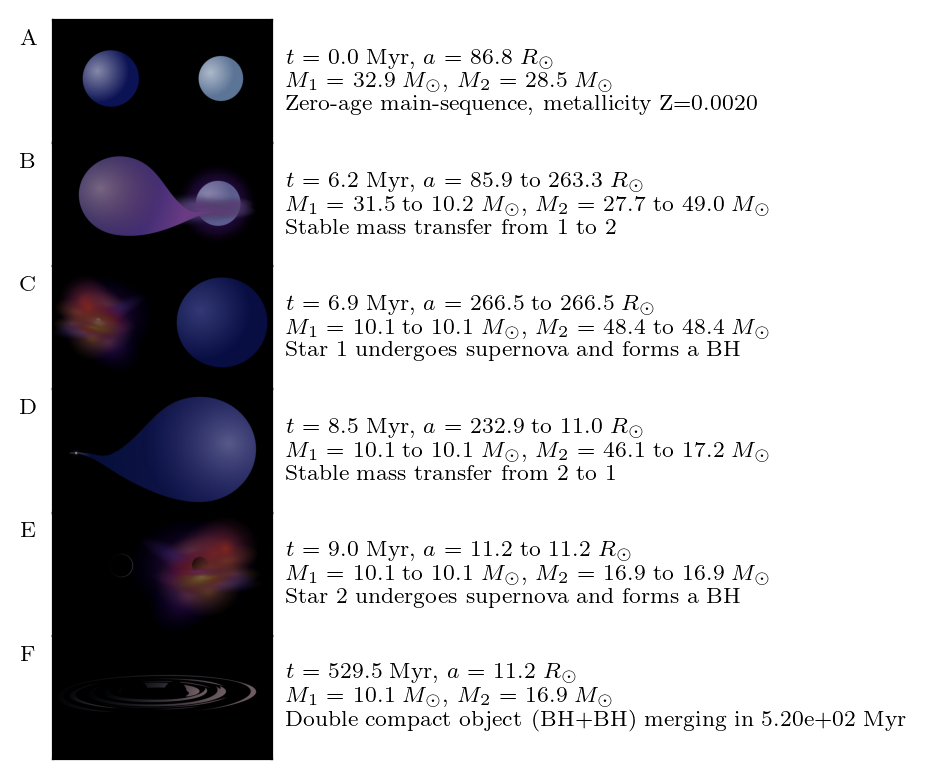

In [175]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [176]:
df_detailed_perfect['Period(1)'] = (2 * np.pi / (df_detailed_perfect['Omega(1)'].values / u.s)).to(u.day)
df_detailed_perfect['Period(2)'] = (2 * np.pi / (df_detailed_perfect['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_perfect['Mass(1)'].values * u.M_sun + df_detailed_perfect['Mass(2)'].values * u.M_sun) / (df_detailed_perfect['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_perfect['Omega_Orb'] = omega_orb.value
df_detailed_perfect['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_perfect_short = df_detailed_perfect[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [177]:
# st_change_idx = np.where((df_detailed_perfect_short['Stellar_Type(1)'] != df_detailed_perfect_short['Stellar_Type(1)'].shift()) | (df_detailed_perfect_short['Stellar_Type(2)'] != df_detailed_perfect_short['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_perfect_short.iloc[st_changes_with_buffer]


In [178]:
df_dco_perfect

,SEED,SemiMajorAxis@DCO,Eccentricity@DCO,Mass(1),Stellar_Type(1),Mass(2),Stellar_Type(2),Coalescence_Time,Time,Merges_Hubble_Time,Recycled_NS(1),Recycled_NS(2),Record_Type
0,902,0.052202,0.0,10.085159,14,16.860128,14,521.104525,9.012482,1,0,0,1


In [179]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

In [180]:
df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)


df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

In [181]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]


,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,32.9017,28.4904,6.264330,5.753160,86.798160,0,1,1,11.954833,11.954833,11.954833,0.000000,0.0000
1430,6.19234,31.4757,27.7219,15.907100,12.331600,88.521212,0,1,1,12.538701,12.538701,12.538701,0.000000,0.0000
1431,6.19234,31.4755,27.7218,15.583600,12.331500,88.956222,0,2,1,12.631317,12.631317,12.631317,0.000000,0.0000
2085,6.19503,31.4747,27.7213,33.486300,12.343900,85.905131,0,2,1,11.987179,11.987179,11.987179,0.000000,0.0000
2086,6.19504,10.2028,48.9933,0.948349,10.239200,263.315476,0,7,1,64.328177,64.328177,64.328177,-21.272000,21.2720
2304,6.83388,10.0928,48.3949,0.942042,11.656900,266.386135,0,7,1,65.852126,65.852126,65.852126,0.000000,0.0000
2305,6.83388,10.0923,48.3927,0.942034,11.656500,266.399037,0,8,1,65.858552,65.858552,65.858552,0.000000,0.0000
2427,6.86139,10.0850,48.3656,1.071950,11.734800,266.549560,0,8,1,65.933290,65.933290,65.933290,0.000000,0.0000
2428,6.86155,10.0850,48.3654,0.000043,11.735300,266.549560,0,14,1,65.933858,65.933858,65.933858,0.000000,0.0000
3597,8.54159,10.0850,46.1341,0.000043,21.628900,275.869053,0,14,1,70.786273,70.786273,70.786273,0.000000,0.0000


# CE binary not able to spin up

In [157]:
notides_DataPath = 'sim_data/ce_notides'
tides_DataPath = 'sim_data/ce_realistic'
perfect_DataPath = 'sim_data/ce_perfect'

# # --------------

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    502.454  0.039
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    507.779  0.039
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    507.794  0.039
  7.879652   Stable mass transfer from 1 to 2    9.959     7     25.019     1   1254.580  0.000
  7.879652   Star 1: CHeB->HeMS                 9.959     7     25.019     1   1254.580  0.000
  8.001234   Star 1: HeMS->HeHG                 9.953     8     25.011     1   1255.142  0.000
  8.029444   Star 1 undergoes supernova and forms a BH    9.951    14     25.009     1   1255.289  0.000
  8.385335   Star 2: MS->HG                     9.951    14     24.986     2   1256.328  0.000
  8.397371   Star 2: HG->CHeB                   9.951    14     24.985     4   1256.365  0.000
  9.112222   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x17405f410>])

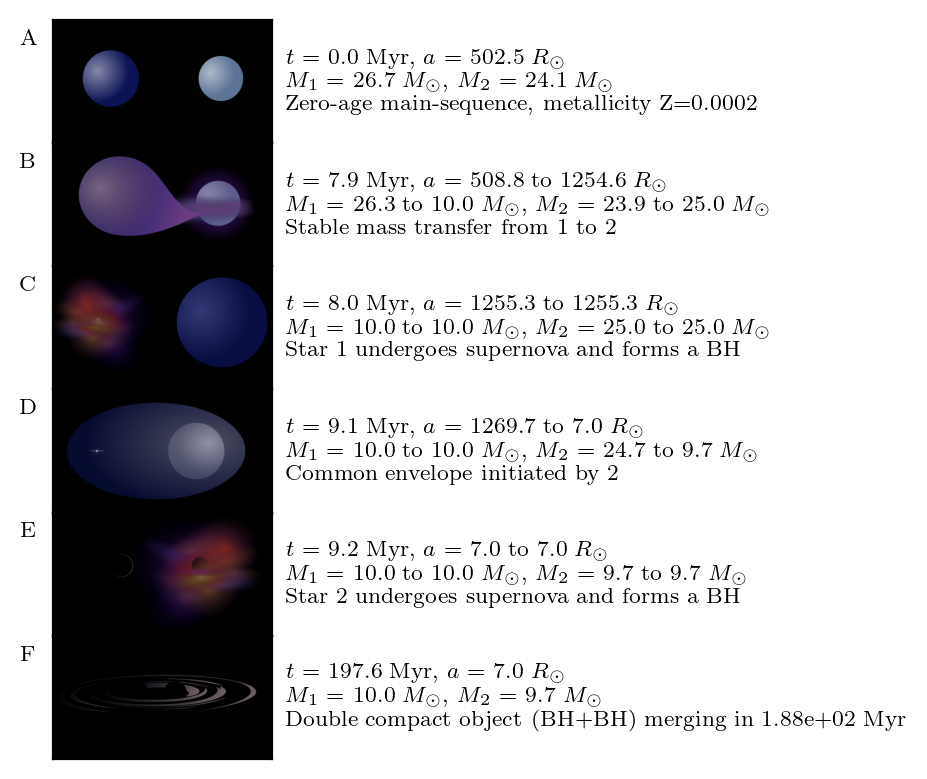

In [158]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [159]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)

df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [160]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,26.70760,24.13840,4.800230,4.521210,502.452736,3.941130e-02,1,1,inf,inf,182.957981,0.000,0.00000
1288,7.30215,26.37570,23.93700,11.701300,10.037000,507.779083,3.941130e-02,1,1,2.474882e+11,2.161911e+11,186.856441,0.000,0.00000
1289,7.30215,26.37560,23.93700,11.495300,10.037000,507.781233,3.941130e-02,2,1,1.673253e+11,2.161891e+11,186.857962,0.000,0.00000
2368,7.31306,26.37480,23.93640,35.714000,10.071500,507.794135,3.941130e-02,2,1,1.594590e+12,2.176571e+11,186.867091,0.000,0.00000
2369,7.31306,26.37470,23.93640,35.712200,10.071500,507.796285,3.941130e-02,4,1,1.594435e+12,2.176510e+11,186.868613,0.000,0.00000
4118,7.87954,26.30450,23.90580,189.173000,12.506800,508.815538,3.941130e-02,4,1,4.042304e+13,3.316680e+11,187.620255,0.000,0.00000
4119,7.87960,9.95851,25.01890,1.022830,11.195800,1254.579308,0.000000e+00,7,1,4.046281e+13,1.949899e+00,870.338032,-16.346,1.11311
4211,8.00123,9.95271,25.01100,0.933968,11.750800,1255.142693,0.000000e+00,7,1,3.384927e+13,2.151937e+00,871.094549,0.000,0.00000
4212,8.00123,9.95260,25.01080,0.933966,11.750800,1255.151294,0.000000e+00,8,1,1.067913e+13,2.151998e+00,871.107775,0.000,0.00000
4338,8.02915,9.95090,25.00910,1.067170,11.889200,1255.286764,0.000000e+00,8,1,1.163529e+13,2.203806e+00,871.292981,0.000,0.00000


### Notides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    502.454  0.039
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    507.779  0.039
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    507.794  0.039
  7.879652   Stable mass transfer from 1 to 2    9.959     7     25.019     1   1254.580  0.000
  7.879652   Star 1: CHeB->HeMS                 9.959     7     25.019     1   1254.580  0.000
  8.001234   Star 1: HeMS->HeHG                 9.953     8     25.011     1   1255.142  0.000
  8.029444   Star 1 undergoes supernova and forms a BH    9.951    14     25.009     1   1255.289  0.000
  8.385335   Star 2: MS->HG                     9.951    14     24.986     2   1256.328  0.000
  8.397371   Star 2: HG->CHeB                   9.951    14     24.985     4   1256.365  0.000
  9.112222   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1746a21d0>])

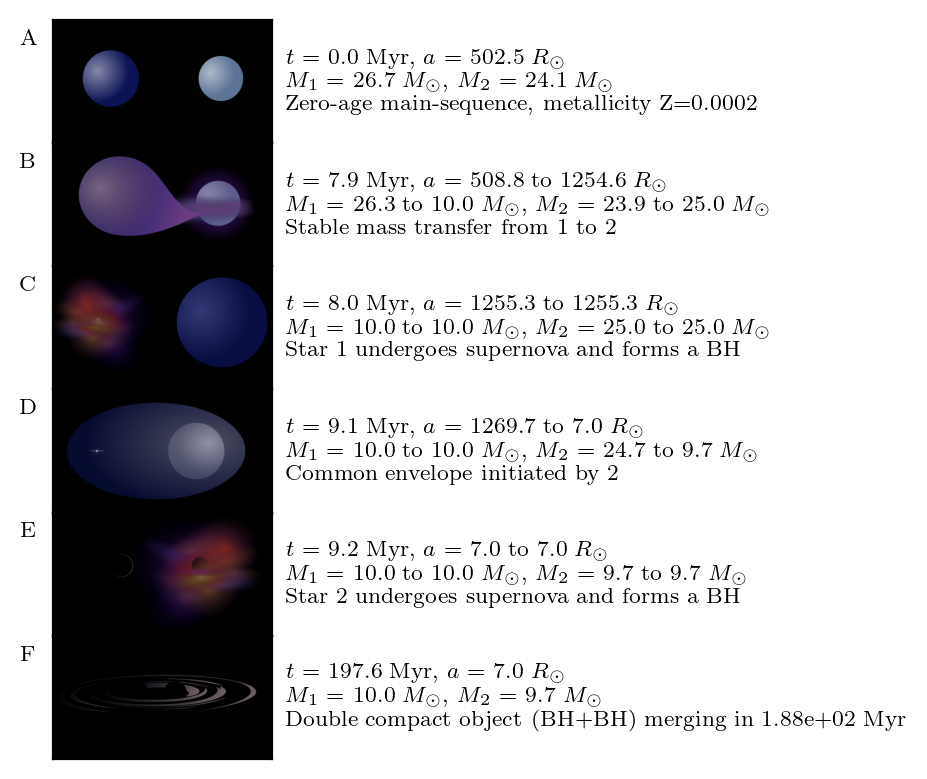

In [164]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [165]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [166]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,26.70760,24.13840,4.800230,4.521210,502.452736,3.941130e-02,1,1,inf,inf,182.957981,0.000,0.00000
1288,7.30215,26.37570,23.93700,11.701300,10.037000,507.779083,3.941130e-02,1,1,inf,inf,186.856441,0.000,0.00000
1289,7.30215,26.37560,23.93700,11.495300,10.037000,507.781233,3.941130e-02,2,1,inf,inf,186.857962,0.000,0.00000
2368,7.31306,26.37480,23.93640,35.714000,10.071500,507.794135,3.941130e-02,2,1,inf,inf,186.867091,0.000,0.00000
2369,7.31306,26.37470,23.93640,35.712200,10.071500,507.796285,3.941130e-02,4,1,inf,inf,186.868613,0.000,0.00000
4118,7.87954,26.30450,23.90580,189.173000,12.506800,508.815538,3.941130e-02,4,1,inf,inf,187.620255,0.000,0.00000
4119,7.87960,9.95851,25.01890,1.022830,11.195800,1254.579308,0.000000e+00,7,1,inf,1.949899,870.338032,-16.346,1.11311
4211,8.00123,9.95271,25.01100,0.933968,11.750800,1255.142693,0.000000e+00,7,1,inf,2.151937,871.094549,0.000,0.00000
4212,8.00123,9.95260,25.01080,0.933966,11.750800,1255.151294,0.000000e+00,8,1,inf,2.151998,871.107775,0.000,0.00000
4338,8.02915,9.95090,25.00910,1.067170,11.889200,1255.286764,0.000000e+00,8,1,inf,2.203806,871.292981,0.000,0.00000


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    501.638  0.000
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    506.802  0.000
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    506.197  0.000
  7.879652   Stable mass transfer from 1 to 2    9.959     7     25.019     1   1286.033  0.000
  7.879652   Star 1: CHeB->HeMS                 9.959     7     25.019     1   1286.033  0.000
  8.001234   Star 1: HeMS->HeHG                 9.953     8     25.011     1   1286.533  0.000
  8.029444   Star 1 undergoes supernova and forms a BH    9.951    14     25.009     1   1286.667  0.000
  8.385319   Star 2: MS->HG                     9.951    14     24.986     2   1287.540  0.000
  8.397355   Star 2: HG->CHeB                   9.951    14     24.985     4   1287.212  0.000
  9.106713   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1731d1750>])

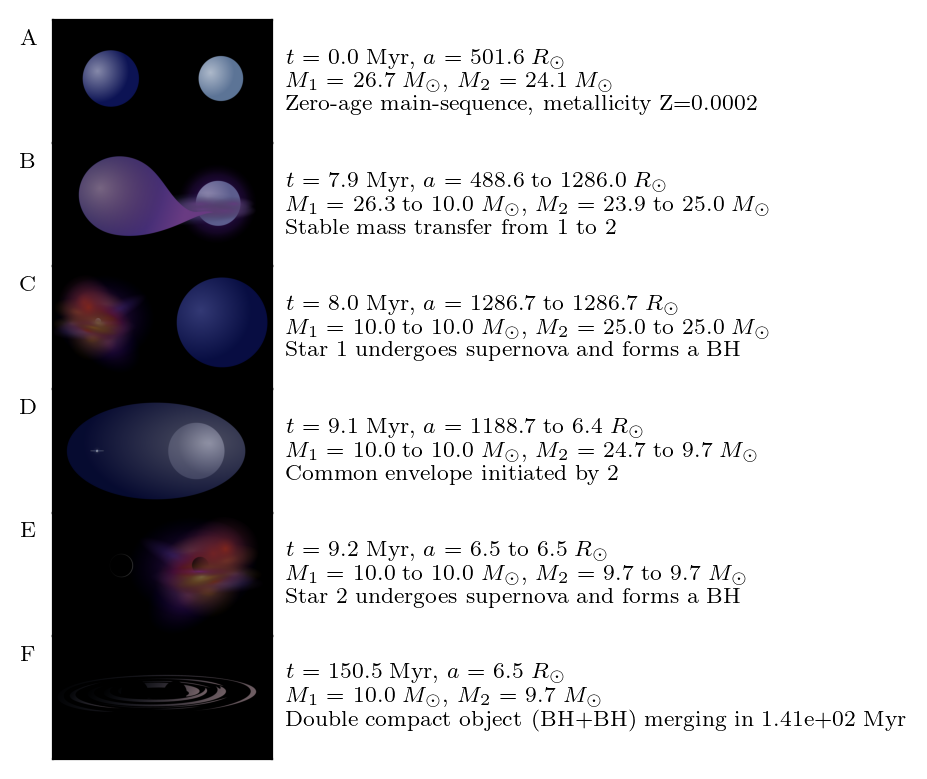

In [161]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [162]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)

df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

In [163]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,dM1_MT,dM2_MT
0,0.00000,26.70760,24.13840,4.800230,4.521210,501.637764,0,1,1,182.512739,182.512739,182.512739,0.000,0.00000
1288,7.30215,26.37570,23.93700,11.701300,10.037000,506.800686,0,1,1,186.317897,186.317897,186.317897,0.000,0.00000
1289,7.30215,26.37560,23.93700,11.495300,10.037000,506.839392,0,2,1,186.339077,186.339077,186.339077,0.000,0.00000
2368,7.31306,26.37480,23.93640,35.714000,10.071500,506.196446,0,2,1,185.985707,185.985707,185.985707,0.000,0.00000
2369,7.31306,26.37470,23.93640,35.712200,10.071500,506.198596,0,4,1,185.988721,185.988721,185.988721,0.000,0.00000
4118,7.87954,26.30450,23.90580,189.173000,12.506800,488.602515,0,4,1,176.552354,176.552354,176.552354,0.000,0.00000
4119,7.87960,9.95851,25.01890,1.022830,11.195800,1286.032062,0,7,1,903.275278,903.275278,903.275278,-16.346,1.11305
4211,8.00123,9.95271,25.01090,0.933968,11.750900,1286.533087,0,7,1,903.979767,903.979767,903.979767,0.000,0.00000
4212,8.00123,9.95260,25.01080,0.933966,11.750900,1286.541688,0,8,1,903.994010,903.994010,903.994010,0.000,0.00000
4338,8.02915,9.95090,25.00910,1.067170,11.889200,1286.666407,0,8,1,904.164966,904.164966,904.164966,0.000,0.00000
